In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/Users/akashkumarsamantray/food-delivery-germany/food-delivery-market-analysis-germany/data/cleaned_reviews.csv')
df['at'] = pd.to_datetime(df['at'])
df.head()

,reviewId,userName,content,score,thumbsUpCount,at,replyContent,repliedAt,appVersion,app_name,review_year,review_month,review_day,review_hour,sentiment,review_length,word_count,has_reply
0,06626e61-d64f-4e6c-933e-d581256aac7b,Sara Levermann,Ich finde diese App sehr gut.🙂...,5,0,2026-06-09 21:59:48,No Reply,NaN,26.23.3,Wolt,2026,6,Tuesday,21,Positive,33,6,0
1,97aad388-9203-45eb-8499-db5de7b7e666,Matthias Ri,If anything goes wrong with an order don't exp...,1,0,2026-06-09 06:17:59,No Reply,NaN,26.22.3,Wolt,2026,6,Tuesday,6,Negative,107,17,0
2,b96870a4-171e-48cc-bf40-3e4140b649cc,Jean Wolff,Menü für 2 Personnen bestellt und gezahlt. Ein...,1,1,2026-06-08 11:58:17,No Reply,NaN,26.22.3,Wolt,2026,6,Monday,11,Negative,409,60,0
3,ec2966b1-2f78-4920-b4be-fb613c8b0689,Latifa Khennoussi,tolle App,5,0,2026-06-07 23:16:23,No Reply,NaN,26.22.3,Wolt,2026,6,Sunday,23,Positive,9,2,0
4,97cf249e-188c-4c95-88f6-0eef32b63e24,Wahid Alisaleha,Super,5,0,2026-06-07 21:40:12,No Reply,NaN,26.22.3,Wolt,2026,6,Sunday,21,Positive,5,1,0


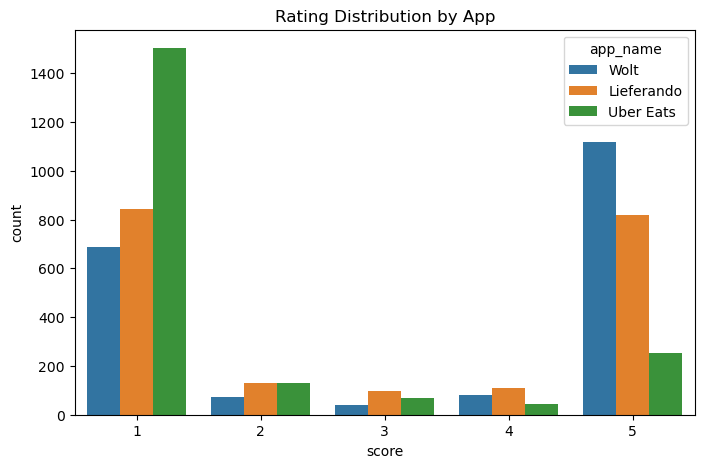

In [12]:
## Overall Rating Distribution

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='score', hue='app_name')
plt.title('Rating Distribution by App')
plt.show()

In [13]:
## Average score per app

df.groupby('app_name')['score'].agg(['mean', 'median', 'count'])

,mean,median,count
app_name,,,
Lieferando,2.966500,3.0,2000
Uber Eats,1.704852,1.0,1999
Wolt,3.434500,5.0,2000


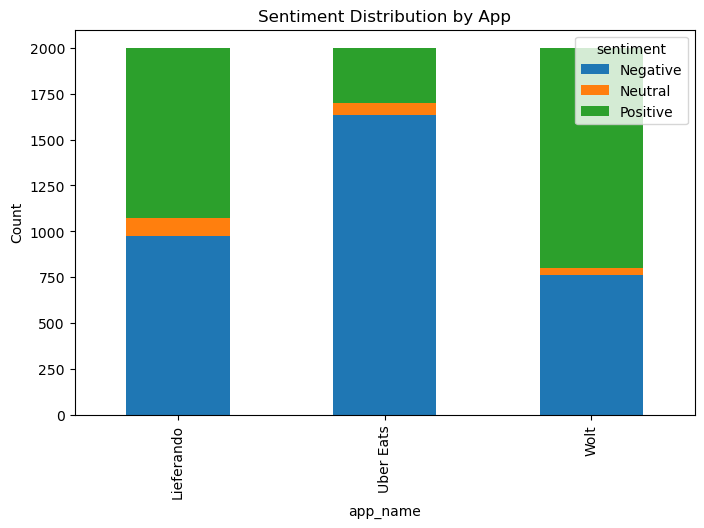

In [14]:
## Sentiment Distribution Per app

sentiment_counts = df.groupby(['app_name', 'sentiment']).size().unstack()
sentiment_counts.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title('Sentiment Distribution by App')
plt.ylabel('Count')
plt.show()

In [ ]:
## Key Insights So Far

In [ ]:
## Wolt has the best average score (3.43) and is the only app where Positive > Negative — strong brand loyalty

In [ ]:
## Uber Eats is in crisis (avg 1.70, ~82% negative reviews) — major customer dissatisfaction

In [ ]:
## Lieferando sits in the middle (2.97), but still majority negative

In [ ]:
## This is a great "Customer Satisfaction Crisis" narrative for your business problem.

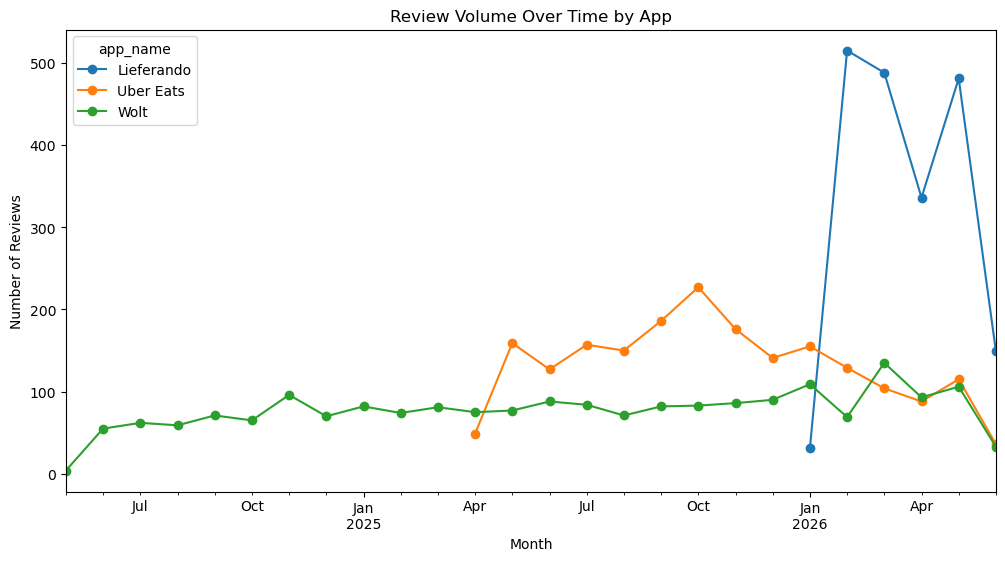

In [15]:
## Reviews over time (trend)

monthly = df.groupby([df['at'].dt.to_period('M'), 'app_name']).size().unstack()
monthly.plot(figsize=(12,6), marker='o')
plt.title('Review Volume Over Time by App')
plt.ylabel('Number of Reviews')
plt.xlabel('Month')
plt.show()

In [16]:
## Average review length by sentiment

df.groupby(['app_name', 'sentiment'])['word_count'].mean().unstack()

sentiment,Negative,Neutral,Positive
app_name,,,
Lieferando,32.105858,22.175258,6.269892
Uber Eats,33.114443,21.588235,8.828283
Wolt,31.207895,32.585366,10.723937


In [17]:
## Thumbs up by sentiment (which complaints resonate most)

df.groupby(['app_name', 'sentiment'])['thumbsUpCount'].mean().unstack()

sentiment,Negative,Neutral,Positive
app_name,,,
Lieferando,1.824255,0.587629,0.100000
Uber Eats,2.988984,0.294118,0.235690
Wolt,4.390789,3.024390,1.349458


In [ ]:
## KEY INSIGHTS

In [ ]:
## Lieferando spike (early 2026): Massive review surge — likely from an app update, price change, or PR event. Worth investigating

In [ ]:
## Negative reviews are 3-4x longer than positive ones across all apps — people write detailed complaints, short praise

In [ ]:
## Wolt's negative reviews get the most thumbs-up (4.39) — meaning other users strongly agree with complaints, 
## even though Wolt has the best average score overall

In [18]:
## Word frequency in negative reviews (what are people complaining about?)

from collections import Counter
import re

extra_stopwords = ['mehr', 'kann', 'bei', 'nur', 'noch', 'wird', 'den', 'dann', 'von',
                    'habe', 'mal', 'wurde', 'hat', 'mir', 'keine', 'bestellt', 'wäre',
                    'schon', 'mich', 'gibt', 'immer', 'wurden', 'können', 'einen',
                    'oder', 'wie', 'als', 'jetzt', 'eine', 'einer', 'wieder', 'hier',
                    'alle', 'gar', 'nie', 'leider', 'app', 'wolt', 'lieferando', 'uber',
                    'bestellung', 'essen']

def get_common_words(text_series, n=15):
    all_words = []
    stopwords = set(['und', 'die', 'der', 'das', 'ist', 'ich', 'nicht', 'für', 'mit',
                      'app', 'auf', 'ein', 'eine', 'sehr', 'es', 'in', 'zu', 'man',
                      'aber', 'wenn', 'sich', 'war', 'auch', 'wie', 'einfach',
                      'the', 'and', 'is', 'to', 'for', 'this', 'it', 'of', 'a'] + extra_stopwords)
    for text in text_series:
        words = re.findall(r'\b[a-zäöüß]+\b', str(text).lower())
        words = [w for w in words if w not in stopwords and len(w) > 2]
        all_words.extend(words)
    return Counter(all_words).most_common(n)

for app in df['app_name'].unique():
    print(f"\n=== {app} - Top Negative Review Words ===")
    negative = df[(df['app_name'] == app) & (df['sentiment'] == 'Negative')]['content']
    print(get_common_words(negative, 15))


=== Wolt - Top Negative Review Words ===
[('was', 107), ('support', 106), ('nach', 104), ('sind', 86), ('werden', 86), ('bestellen', 81), ('kundenservice', 79), ('über', 79), ('dass', 78), ('meine', 70), ('geliefert', 65), ('dem', 62), ('restaurant', 59), ('kalt', 57), ('lieferung', 55)]

=== Lieferando - Top Negative Review Words ===
[('bewertungen', 208), ('über', 135), ('werden', 131), ('was', 126), ('dass', 124), ('restaurant', 123), ('sind', 115), ('nach', 112), ('bestellen', 106), ('sie', 84), ('lesen', 84), ('gutschein', 83), ('geld', 80), ('service', 79), ('kundenservice', 76)]

=== Uber Eats - Top Negative Review Words ===
[('support', 278), ('werden', 238), ('dass', 219), ('über', 212), ('nach', 203), ('was', 197), ('eats', 190), ('geld', 156), ('fahrer', 155), ('dem', 146), ('sind', 145), ('bestellen', 144), ('kein', 142), ('gutschein', 142), ('funktioniert', 141)]


In [ ]:
## KEY COMPLAINT THEMES FOR ALL APPS

In [ ]:
## WOLT

## Customer service (support, kundenservice), food quality (kalt = cold food), delivery issues (geliefert, lieferung)

In [ ]:
## LIFERANDO

## Fake/manipulated reviews (bewertungen, lesen = read reviews), refunds (gutschein, geld), customer service

In [ ]:
## UBER EATS

## Customer support failures (support, funktioniert = doesn't work), money/refunds (geld, gutschein), driver issues (fahrer)

In [ ]:
## BUSINESS PROBLEM STATEMENT:

## "Customer Service & Trust Crisis in Germany's Food Delivery Market: A Comparative Analysis of Wolt, Lieferando, and Uber Eats"


## Despite high order volumes, all three platforms suffer from majority-negative reviews (51-82%), driven by recurring complaints around customer support, 
## refunds/vouchers, and service reliability — with Uber Eats facing the most severe crisis (85% negative).

In [10]:
### Save EDA summary stats for Tableau

summary_stats = df.groupby('app_name').agg(
    avg_score=('score', 'mean'),
    total_reviews=('score', 'count'),
    negative_pct=('sentiment', lambda x: (x == 'Negative').mean() * 100),
    positive_pct=('sentiment', lambda x: (x == 'Positive').mean() * 100),
    avg_thumbsup_negative=('thumbsUpCount', 'mean')
).reset_index()

summary_stats.to_csv('data/summary_stats.csv', index=False)
summary_stats

,app_name,avg_score,total_reviews,negative_pct,positive_pct,avg_thumbsup_negative
0,Lieferando,2.966500,2000,48.65000,46.500000,0.962500
1,Uber Eats,1.704852,1999,81.74087,14.857429,2.488244
2,Wolt,3.434500,2000,38.00000,59.950000,2.539500


In [ ]:
## Final EDA Summary

In [ ]:
## Wolt: Best performer (59.95% positive, avg 3.43)

In [ ]:
## Lieferando: Split sentiment, but review manipulation concerns stand out as unique issue

In [ ]:
## Uber Eats: Crisis mode — 81.74% negative, avg score barely above 1.7